In [ ]:
import logging
#import anndata2ri
#import rpy2.rinterface_lib.callbacks as rcb
#import rpy2.robjects as ro
#from rpy2.robjects import pandas2ri
import scanpy as sc
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.sparse import issparse
from scipy.sparse import csr_matrix
sc.settings.verbosity = 0
sc.set_figure_params(
    dpi=80,
    facecolor="white",
    # color_map="YlGnBu",
    frameon=False,
)

#rcb.logger.setLevel(logging.ERROR)
#anndata2ri.set_ipython_converter()
#%load_ext rpy2.ipython

In [2]:
import warnings 
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', RuntimeWarning)

In [2]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system_normalized.h5ad")
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features'
    uns: 'ClusterSystem_colors', 'log1p'
    obsm: 'X_umap'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'

In [ ]:
adata = adata.to_df(layer = "raw_counts")


: 

In [ ]:
raw_count.sum(axis=0).sort_values(ascending=False)

Malat1           3271810.0
Gpc6             1177071.0
Dcc               648223.0
Efna5             602477.0
Hnrnpa2b1         551318.0
                   ...    
3110004A20Rik          0.0
Gabra6                 0.0
Gm28440                0.0
Gm29091                0.0
Gm29297                0.0
Length: 33696, dtype: float64

## Exploring 3 normalization techniques

In [4]:
# Resetting the default X layer to raw_counts for normalizations
adata.X = adata.layers["raw_counts"]
adata.to_df() 

: 

#### Method 1: Log scale normalization 
Normalizes the raw data - > converting it into log scale 

In [ ]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)
# TODO: Scale it and graph

Visualizing the change

In [ ]:
# Need to add a total_counts observation to adata
adata.obs["total_counts"] = adata.X.sum(axis=1)

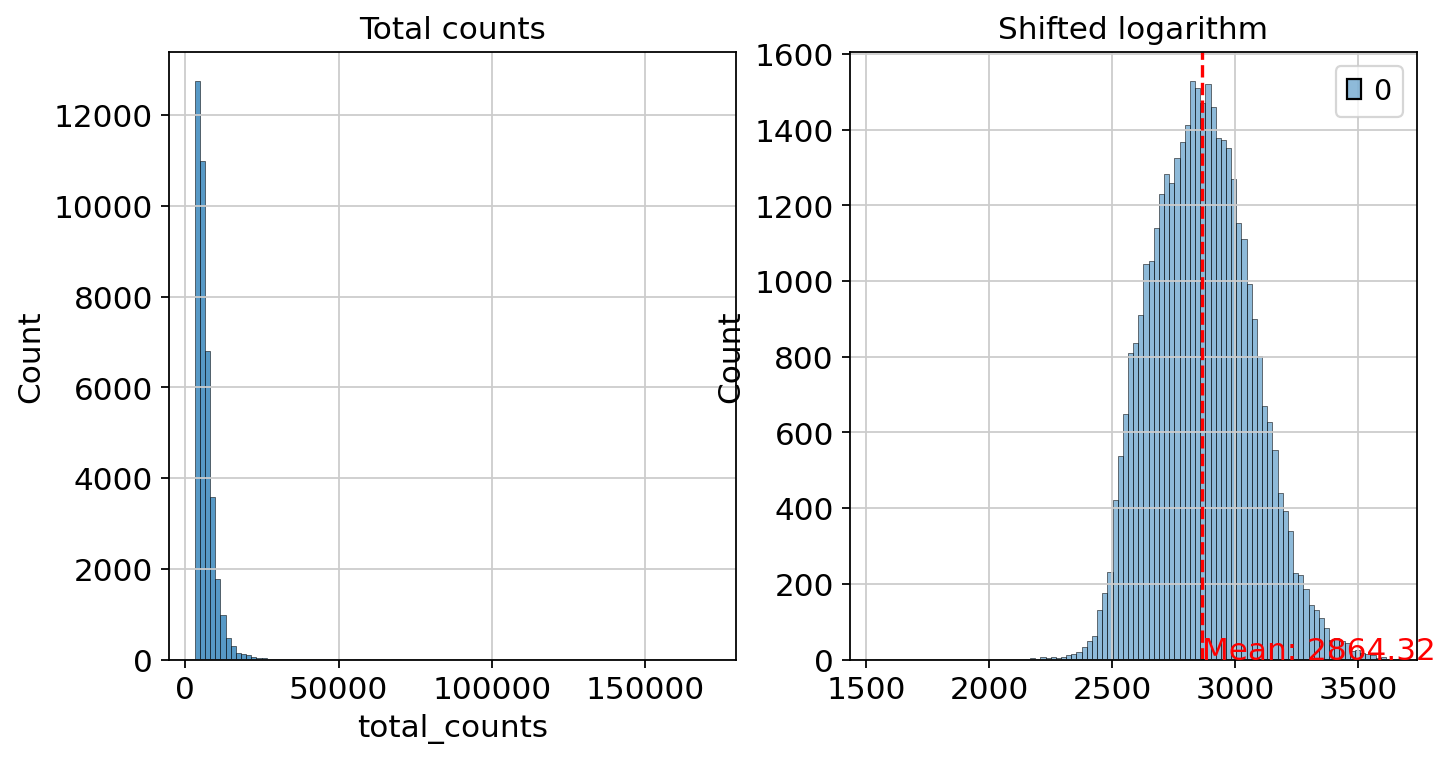

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
mean_log1p = adata.layers["log1p_norm"].sum(1).mean()
axes[1].text(mean_log1p, 0.5, f'Mean: {mean_log1p:.2f}', color='red')
axes[1].axvline(mean_log1p, color='red', linestyle='--')
axes[1].set_title("Shifted logarithm")
plt.show()

In [13]:
np.std(adata.layers["log1p_norm"].sum(1))

202.49500801377567

#### Method 2:  Scran’s pooling-based size factor estimation method
similar to first method, but more steps to define s, the size factor. Not really sure what convolution approach is and how it is different from the other approach in first method
- useful for batch correction, although not sure if we done it this method how it will change the integration harmonization step later.
    - Could test by comparing both normalization type with the integration to see if anything changed

In [ ]:
%%R
#install.packages("BiocManager")
#BiocManager::install("scran") <- this thing took like 20 mins to install
library(scran)
library(BiocParallel)

Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: 'MatrixGenerics'

The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [ ]:
# Preliminary clustering for differentiated normalisation
# Setting default to log again
adata_pp = adata.copy()
adata_pp.X = adata.layers["log1p_norm"]


In [ ]:
# Skip normalization since we already done it
#sc.pp.normalize_total(adata_pp)
#sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="groups")

In [ ]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()

from rpy2.robjects.conversion import localconverter
# Use the converter as a context manager to handle the sparse matrix
with localconverter(anndata2ri.converter):
    ro.globalenv["data_mat"] = data_mat
    ro.globalenv["input_groups"] = adata_pp.obs["groups"]

In [ ]:
del adata_pp

In [ ]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [ ]:
adata.obs["size_factors"] = size_factors
scran = adata.X/ adata.obs["size_factors"].values[:, None]
adata.layers["scran_normalization"] = csr_matrix(np.log1p(scran))

In [ ]:
adata.layers["scran_normalization"].toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.78781774, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.70733376]], shape=(38311, 33696))

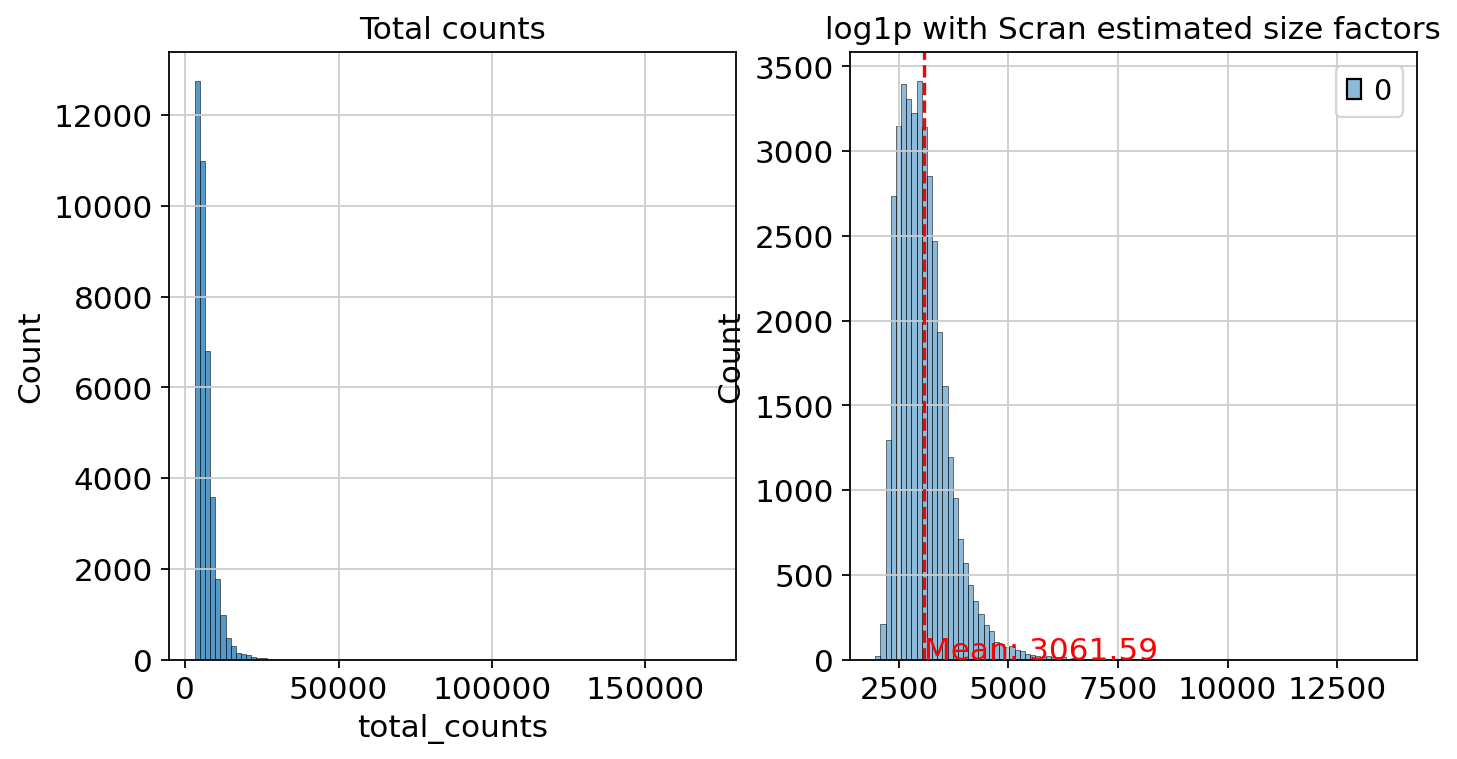

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("log1p with Scran estimated size factors")
axes[1].axvline(adata.layers["scran_normalization"].sum(1).mean(), color='red', linestyle='--')
axes[1].text(adata.layers["scran_normalization"].sum(1).mean(), 0.5, f'Mean: {adata.layers["scran_normalization"].sum(1).mean():.2f}', color='red')
plt.show()

In [ ]:
# Scran std
np.std(adata.layers["scran_normalization"].sum(1))

615.6125093542008

#### Method 3: Pearson Residual 
uses "regularized negative binomial regrssion" to calculate the noise within a data. 
- remove sampling effect while preserving heterogenity within cell
- Nice thing about this is output could be positive or negative, representing more expressed or less expressed than the average expression of gene (need to find how the average is calculated)

In [ ]:
analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)


/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/site-packages/scanpy/experimental/pp/_normalization.py:76: RuntimeWarning: invalid value encountered in divide
  residuals = diff / np.sqrt(mu + mu**2 / theta)


NameError: name 'csr_matrix' is not defined

In [4]:
# Replacing the NaN generated from the normalization to 0 
analytic_pearson_array = np.nan_to_num(adata.layers["analytic_pearson_residuals"].toarray(),nan=0.0)





In [6]:
adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])

In [ ]:
# Std for pearson
np.std(analytic_pearson_array.sum(1))

420.7565970243451

In [ ]:
# std for raw count
df = adata.obs["total_counts"]

In [11]:
df.std()

4081.1386411963035

In [8]:
print(csr_matrix(analytic_pearson["X"]))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1290927456 stored elements and shape (38311, 33696)>
  Coords	Values
  (0, 0)	-0.5125462905346542
  (0, 1)	-0.10973456575370624
  (0, 2)	-0.07964688510981602
  (0, 3)	-0.017773132843978884
  (0, 4)	-0.1040723710481956
  (0, 5)	-0.07470159288549982
  (0, 6)	-0.010883787393420795
  (0, 7)	-0.014511709839519368
  (0, 8)	-0.37394316495141683
  (0, 9)	-0.06377191529085652
  (0, 10)	-0.46866727419831794
  (0, 11)	-0.7014783491442034
  (0, 12)	-0.3862182878941988
  (0, 13)	-0.02856624290905917
  (0, 14)	-0.5497648929852029
  (0, 15)	-0.048265924203272935
  (0, 16)	-0.023789869017779332
  (0, 17)	-0.323408852746736
  (0, 18)	0.9088131833171627
  (0, 19)	-0.07712858278600941
  (0, 20)	-0.1491262539167142
  (0, 21)	-0.04531238197590648
  (0, 22)	2.4478582239105413
  (0, 23)	-0.3619748204264947
  (0, 24)	-0.012567512681609067
  :	:
  (38310, 33671)	nan
  (38310, 33672)	-0.07086216841764173
  (38310, 33673)	nan
  (38310, 33674)	nan
  (3

In [ ]:
adata.obs

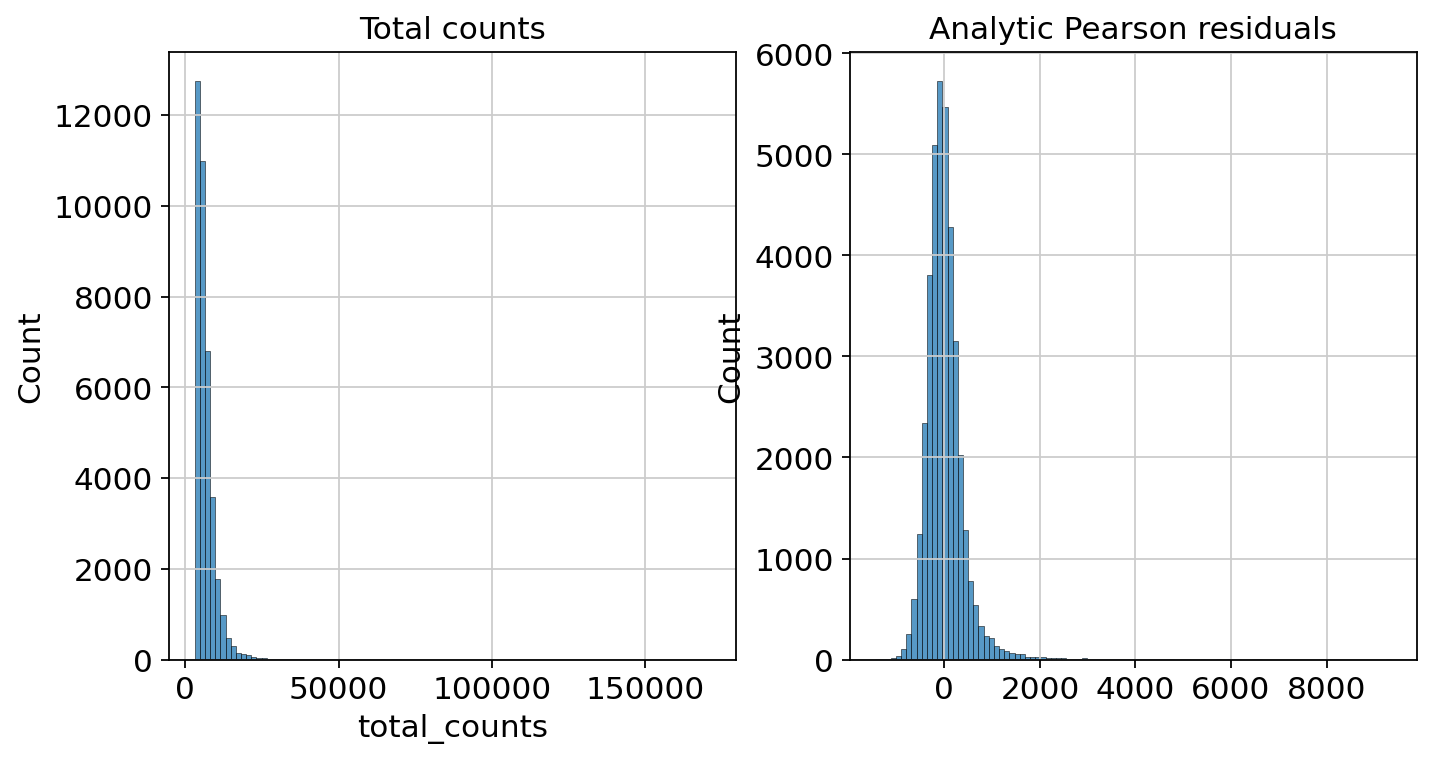

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    analytic_pearson_array.sum(1), bins=100, kde=False, ax=axes[1]
)

axes[1].set_title("Analytic Pearson residuals")
plt.show()

In [ ]:
#adata.write_h5ad("SmoNull_Brain_system_normalized.h5ad")